In [1]:
import jets
import jets.metrics as metrics

In [2]:
config = {
    'exp_name': 'test',
    'visual': {
        'fields': ['q', 'v'],
        'spectra': ['z', 'e'],
        # 'means' : ['z_mean', 'e_mean'],
        'means' : ['z_dot', 'e_dot'],
    },
    'atmosphere': {
        'n_grid': 256, 
        'params': {
            'initial': 'zero', 
            'forcing': 'norm',
            'p': 2,
            'nu': 4e-8, 
            'r': 0.1,
            'epsilon': 10.0,
            'kf': 16,
            'dkf': 2,
            'forcing_dt': 0.1/100,
        }
    },
    'integrator': {
        'method': 'rk4',
        'interval': 0.1,
        'n_points': 100,
    },
}

model = jets.Driver()
model.setup(**config)
model.start()
print(model.descript())

def check_z_saturation(climate, show=False):
    if len(climate['t'])<=2:
        return False, None
    t, z_mean = climate['t'][1::], climate['z_mean'][1::]
    z_params, z_found = metrics.find_saturation(t, z_mean)
    if z_found:
        if show:
            metrics.plot_saturation(t, z_mean, z_params, 'z_mean')
        return True, z_params
    else:
        return False, None
    
def check_e_saturation(climate, show=False):
    if len(climate['t'])<=2:
        return False, None
    t, e_mean = climate['t'][1::], climate['e_mean'][1::]
    e_params, e_found = metrics.find_saturation(t, e_mean)
    if e_found:
        if show:
            metrics.plot_saturation(t, e_mean, e_params, 'e_mean')
        return True, e_params
    else:
        return False, None
    
def check_saturation(climate, show=False):
    stop_z, data_z = check_z_saturation(climate, show)
    stop_e, data_e = check_e_saturation(climate, show)
    stop = stop_e and stop_z
    data = {
        'e_mean': data_e,
        'z_mean': data_z
    }
    return stop, data

[meta]
model = qgc-1
type = quasi-geostrophic
coord = cartesian
approach = spectral-1

[atmosphere]
initial = zero
forcing = norm
initial_seed = 42
forcing_seed = 42
p = 2
beta = 0.0
nu = 4e-08
r = 0.1
kappa = 0.0
epsilon = 10.0
kf = 16
dkf = 2
sigma = 1.0
forcing_dt = 0.001

[integrator]
method = rk4
interval = 0.1
n_points = 100




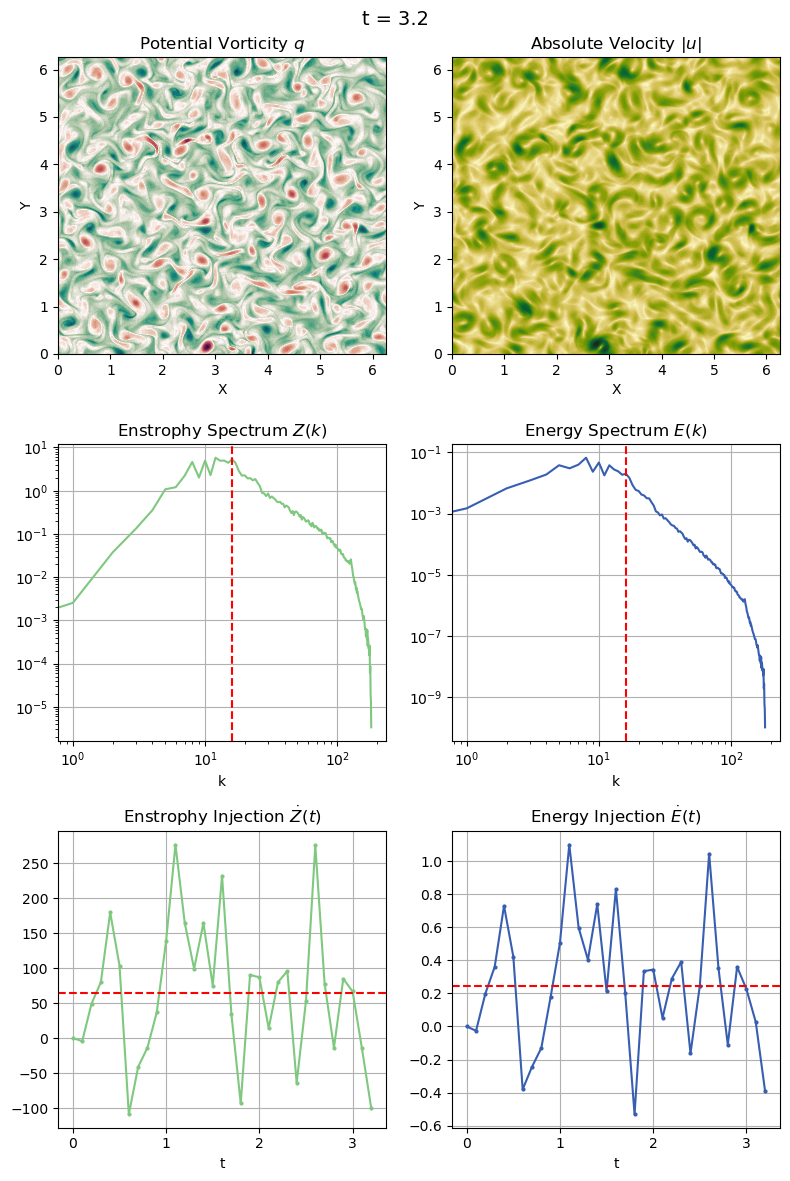

In [ ]:
data = model.run(71, show=True) #logtime=True, tau=2, metrics=check_saturation)

In [101]:
climate = model.climate

In [102]:
e_dot = climate['e_dot'].mean()
z_dot = climate['z_dot'].mean()

z_dot, e_dot
# print(1/climate['e_mean'].values[-1]**0.5)

(<xarray.DataArray 'z_dot' ()> Size: 8B
 Array(4.90300648, dtype=float64),
 <xarray.DataArray 'e_dot' ()> Size: 8B
 Array(0.01871017, dtype=float64))

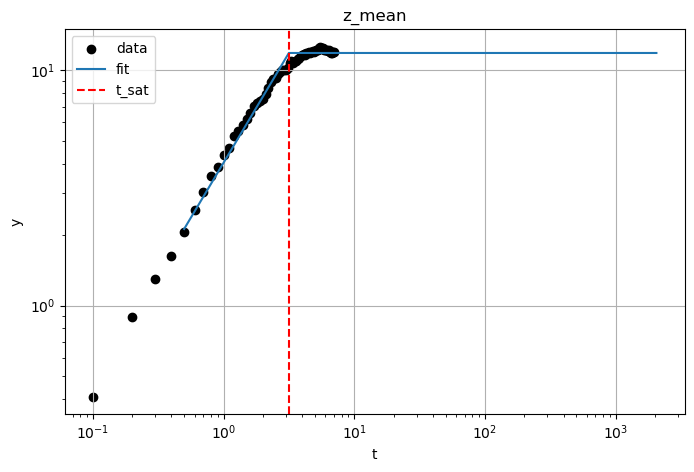

z_mean:
A = 1.18e+01
alpha = 0.93
t_sat = 3


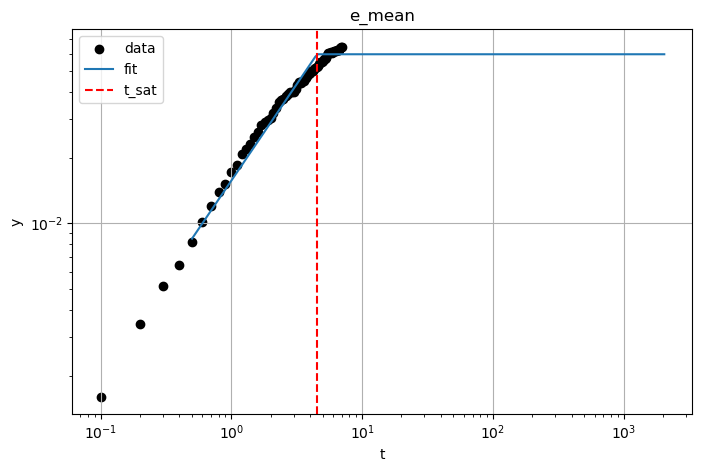

e_mean:
A = 5.96e-02
alpha = 0.88
t_sat = 5


{'e_mean': {'alpha': np.float64(0.8847212249387744),
  'A': np.float64(0.05958685378657627),
  't_sat': np.float64(4.517301370792704)},
 'z_mean': {'alpha': np.float64(0.9338639098566395),
  'A': np.float64(11.827871027632165),
  't_sat': np.float64(3.1573643554034865)}}

In [103]:
_, data = check_saturation(climate, show=True)
data

In [104]:
data['e_mean']
t_sat = data['e_mean']['t_sat']
t_sat_theory = 1/(2*config['atmosphere']['params']['r'])
t_sat, t_sat_theory

(np.float64(4.517301370792704), 5.0)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output


t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
print(t_sat, t_sat_theory, N_oct, С_cas)

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
# e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = 1, 3.88
log_y = a * np.log(t[t<4]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<4], np.exp(log_y))
plt.axvline(t_sat, color='b', linestyle='--', label='t_sat')
plt.axvline(t_sat_theory, color='r', linestyle='--', label='t_theory')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

3.1573643554034865 <xarray.DataArray 'z_dot' ()> Size: 8B
Array(1.01785296, dtype=float64) 1.7291760009659192 <xarray.DataArray 'z_dot' ()> Size: 8B
array(3.10198475)


/home/vchernosov/miniconda3/envs/climate/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


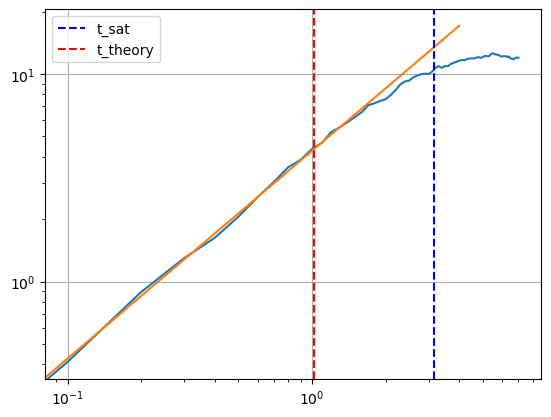

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output


t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
print(t_sat, t_sat_theory, N_oct, С_cas)

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
# e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = 1, 1.45
log_y = a * np.log(t[t<4]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<4], np.exp(log_y))
plt.axvline(t_sat, color='b', linestyle='--', label='t_sat')
plt.axvline(t_sat_theory, color='r', linestyle='--', label='t_theory')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

In [73]:
import numpy as np
C_cas_0 = 1.37
data['z_mean']
t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
tau_nl = (eta)**(-1/3)
k_diss = 1/(tau_nl * nu)**(1/(2*p))
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
t_sat, t_sat_theory, N_oct, С_cas

(np.float64(4.239964293218197),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 Array(2.15557673, dtype=float64),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(2.14149174),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(1.96697443))

/home/vchernosov/miniconda3/envs/climate/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


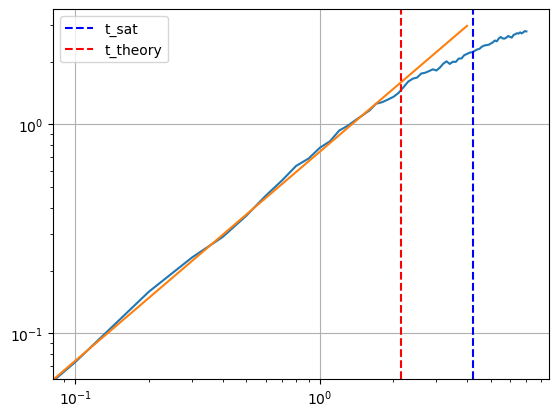

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output


t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
# e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = 1, -0.3
log_y = a * np.log(t[t<4]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<4], np.exp(log_y))
plt.axvline(t_sat, color='b', linestyle='--', label='t_sat')
plt.axvline(t_sat_theory, color='r', linestyle='--', label='t_theory')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

In [37]:
import numpy as np
C_cas_0 = 1.37
data['z_mean']
t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
tau_nl = (eta)**(-1/3)
k_diss = 1/(tau_nl * nu)**(1/(2*p))
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
t_sat, t_sat_theory, N_oct, С_cas

(np.float64(1.7603000382257978),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 Array(0.66778615, dtype=float64),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(2.63956699),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(2.63602359))

/home/vchernosov/miniconda3/envs/climate/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


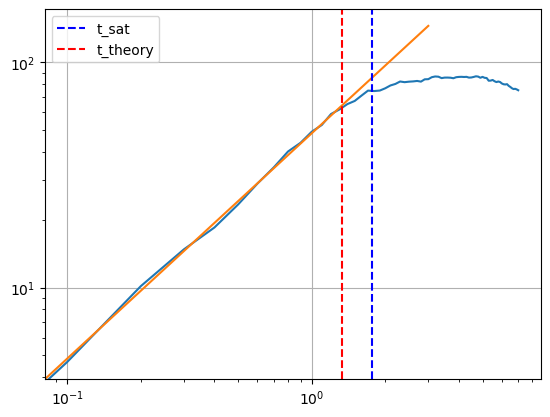

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
k_nl = 1/(tau_nl * nu)**(1/(2*p))

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
# e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = 1, 3.88
log_y = a * np.log(t[t<3]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<3], np.exp(log_y))
plt.axvline(t_sat, color='b', linestyle='--', label='t_sat')
plt.axvline(2*t_sat_theory, color='r', linestyle='--', label='t_theory')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

In [30]:
import numpy as np
C_cas_0 = 1.37
data['z_mean']
t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
tau_nl = (eta)**(-1/3)
k_diss = 1/(tau_nl * nu)**(1/(2*p))
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
t_sat, t_sat_theory, N_oct, С_cas

(np.float64(1.6051171148634689),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 Array(0.51451103, dtype=float64),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(2.05907416),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(3.1196943))

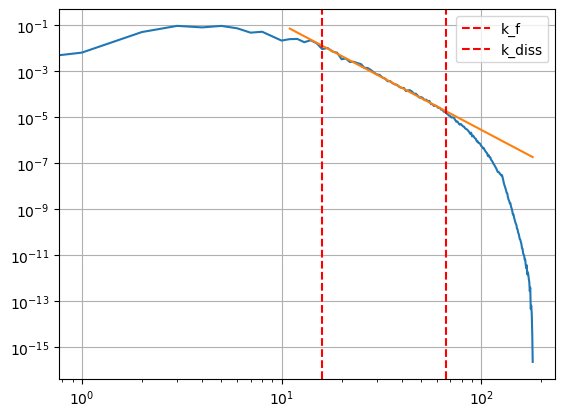

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
k_nl = 1/(tau_nl * nu)**(1/(2*p))

E, Z, k1 = climate['e'], climate['z'], climate['k1']
e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = -4.6, 8.4 
log_y = a * np.log(k1[k1>10]) + b 
plt.loglog(k1, e)
plt.loglog(k1[k1>10], np.exp(log_y))
plt.axvline(kf, color='r', linestyle='--', label='k_f')
plt.axvline(k_nl, color='r', linestyle='--', label='k_diss')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

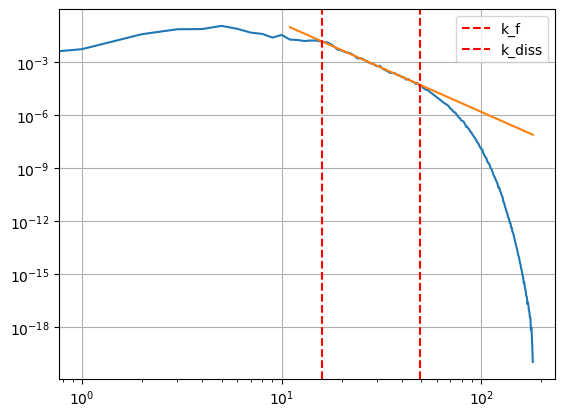

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
k_nl = 1/(tau_nl * nu)**(1/(2*p))

E, Z, k1 = climate['e'], climate['z'], climate['k1']
e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = -5, 9.6
log_y = a * np.log(k1[k1>10]) + b 
plt.loglog(k1, e)
plt.loglog(k1[k1>10], np.exp(log_y))
plt.axvline(kf, color='r', linestyle='--', label='k_f')
plt.axvline(k_nl, color='r', linestyle='--', label='k_diss')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

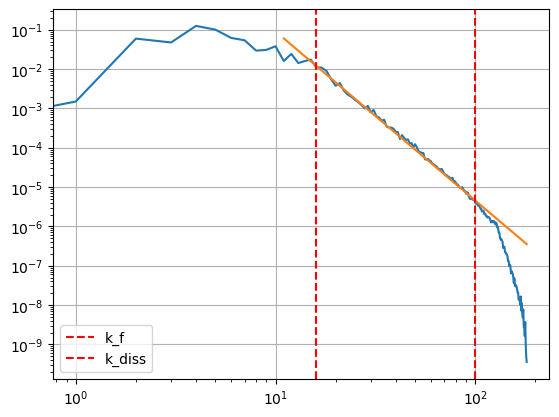

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
k_nl = 1/(tau_nl * nu)**(1/(2*p))

E, Z, k1 = climate['e'], climate['z'], climate['k1']
e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = -4.3, 7.5
log_y = a * np.log(k1[k1>10]) + b 
plt.loglog(k1, e)
plt.loglog(k1[k1>10], np.exp(log_y))
plt.axvline(kf, color='r', linestyle='--', label='k_f')
plt.axvline(k_nl, color='r', linestyle='--', label='k_diss')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

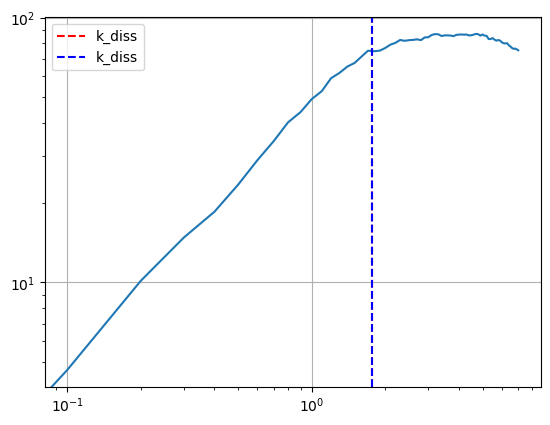

<xarray.DataArray 'z_dot' ()> Size: 8B
Array(1.77093555, dtype=float64) 1.7603000382257978


In [88]:
e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
plt.loglog(t, z_mean)
plt.axvline(data['z_mean']['t_sat'], color='r', linestyle='--', label='k_diss')
plt.axvline(tau_nl*7, color='b', linestyle='--', label='k_diss')
plt.legend()
plt.grid(True)
plt.show()
print(tau_nl*7, data['z_mean']['t_sat'])